<a href="https://colab.research.google.com/github/Ammar-creator-cmd/DataVisualization/blob/main/SpamEmail_Dtector.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Data Collection

In [72]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn

In [73]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [74]:
spam = pd.read_csv("/content/drive/MyDrive/dataset/spam.csv")

In [75]:
spam.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


### Data Processing

In [76]:
email1 = spam[spam["Category"]==0]
email2 = spam[spam["Category"]==1]

In [77]:
print(email1)

Empty DataFrame
Columns: [Category, Message]
Index: []


In [78]:
print(email2)

Empty DataFrame
Columns: [Category, Message]
Index: []


In [79]:
spam.shape

(5572, 2)

In [80]:
spam.tail()

,Category,Message
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...
5571,ham,Rofl. Its true to its name


In [81]:
spam.columns = spam.columns.str.strip()

In [82]:
spam.columns = spam.columns.str.lower()

In [83]:
spam.head()

,category,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [84]:
spam.isna().sum()

,0
category,0
message,0


In [85]:
spam[spam.duplicated(subset = ["category", "message"], keep = False)]

,category,message
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
7,ham,As per your request 'Melle Melle (Oru Minnamin...
8,spam,WINNER!! As a valued network customer you have...
9,spam,Had your mobile 11 months or more? U R entitle...
11,spam,"SIX chances to win CASH! From 100 to 20,000 po..."
...,...,...
5524,spam,You are awarded a SiPix Digital Camera! call 0...
5535,ham,"I know you are thinkin malaria. But relax, chi..."
5539,ham,Just sleeping..and surfing
5553,ham,Hahaha..use your brain dear


In [86]:
spam.drop_duplicates(subset = ["category", "message"], keep = "first", inplace = True) #dropping duplicates permanently

In [87]:
spam.shape

(5157, 2)

In [88]:
spam.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5157 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   category  5157 non-null   object
 1   message   5157 non-null   object
dtypes: object(2)
memory usage: 120.9+ KB


In [89]:
spam["category"].value_counts().to_frame()

,count
category,
ham,4516
spam,641


In [90]:
spam.loc[spam["category"] == "spam", "category"] = 1
spam.loc[spam["category"] == "ham", "category"] = 0

In [91]:
spam.head()

,category,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [92]:
spam["category"] = spam["category"].astype("int64")

In [93]:
spam.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5157 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   category  5157 non-null   int64 
 1   message   5157 non-null   object
dtypes: int64(1), object(1)
memory usage: 249.9+ KB


### Data Exploration

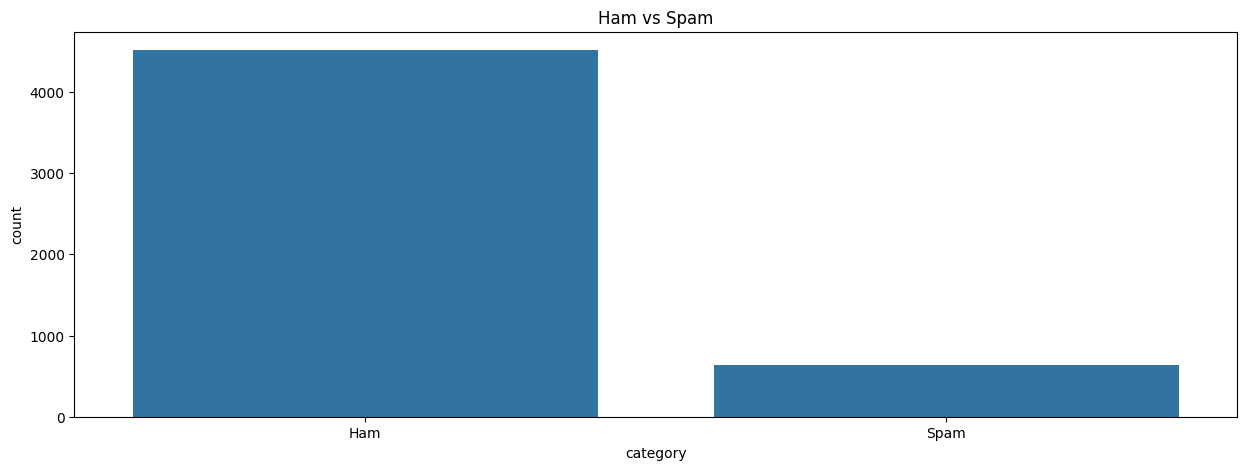

In [94]:
plt.figure(figsize = (15, 5))
sns.countplot(data = spam, x = "category")
plt.title("Ham vs Spam")
plt.xticks([0, 1], ['Ham', 'Spam'])
plt.show()

In [95]:
email1 = spam[spam["category"]==0]
email2 = spam[spam["category"]==1]

In [96]:
email1_sample = email1.sample(n = 641, replace = False, random_state = 42)

In [97]:
spamdata = pd.concat([email1_sample, email2])

In [98]:
spamdata["category"].value_counts().to_frame()

,count
category,
0,641
1,641


<Axes: xlabel='category', ylabel='count'>

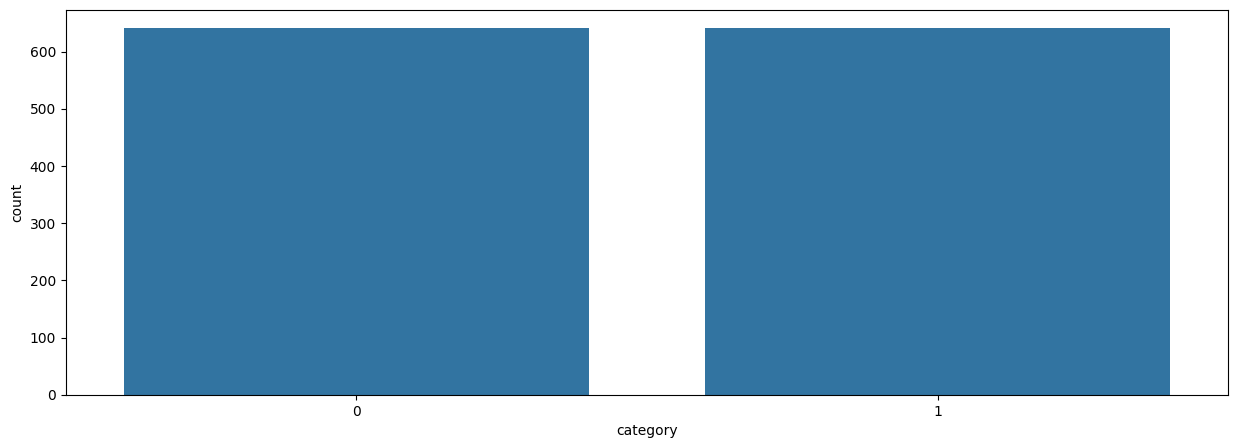

In [99]:
plt.figure(figsize = (15, 5))
sns.countplot(data = spamdata, x = "category")

In [100]:
x = spamdata["message"]
y = spamdata["category"]

In [101]:
from sklearn.model_selection import train_test_split

In [102]:
x_train, x_test, y_train, y_test = train_test_split (x, y, test_size = 0.2, random_state = 42)

In [103]:
from sklearn.feature_extraction.text import TfidfVectorizer

tf = TfidfVectorizer(min_df = 1, stop_words = "english", lowercase = True)

In [104]:
x_train_tf = tf.fit_transform(x_train)
x_test_tf = tf.transform(x_test)

In [105]:
x_train_tf

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 11060 stored elements and shape (1025, 3652)>

In [106]:
from sklearn.linear_model import LogisticRegression

In [107]:
lr = LogisticRegression(max_iter = 800)

In [108]:
lr.fit(x_train_tf, y_train)

LogisticRegression(max_iter=800)

In [109]:
lr.score(x_train_tf, y_train)

0.9882926829268293

In [110]:
lr.score(x_test_tf, y_test)

0.9494163424124513

In [111]:
y_predict = lr.predict(x_test_tf)

In [112]:
from sklearn.metrics import confusion_matrix,recall_score,precision_score,accuracy_score,f1_score,ConfusionMatrixDisplay

In [113]:
precision_score(y_test, y_predict)

0.9727272727272728

In [114]:
accuracy_score(y_test, y_predict)

0.9494163424124513

In [115]:
f1_score(y_test, y_predict)

0.9427312775330396

In [116]:
lr.classes_

array([0, 1])

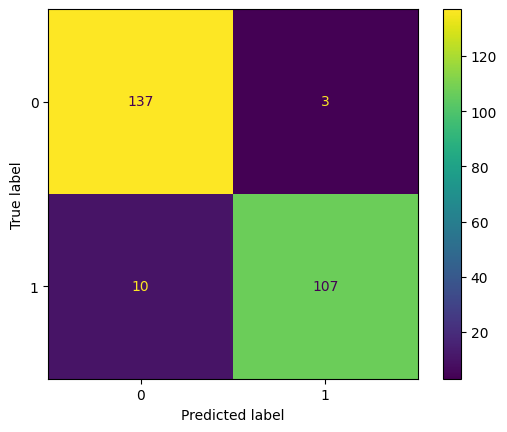

In [117]:
cm=ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test,y_predict,labels=lr.classes_),display_labels=lr.classes_)
cm.plot()

In [ ]:
entermail = [input('enter mail: ')]

In [ ]:
checkmail = tf.transform(entermail)

In [ ]:
predict=lr.predict(checkmail)
if predict==1:
    print('mail is spam')
else:
    print('mail is not spam')